In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("credit_fraud.csv")

In [3]:
df

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41.0,2453.81,12686.50,21.0,0.0,9.0,0.0,2438.2,5.2,0
1,49.0,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1
2,38.0,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0
3,38.0,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5,1
4,61.0,12914.13,2013.73,34.0,0.0,NaN,0.0,4366.7,9.7,1
...,...,...,...,...,...,...,...,...,...,...
32295,52.0,7033.85,7657.07,40.0,0.0,6.0,0.0,304.7,8.2,0
32296,48.0,8974.84,22418.91,49.0,0.0,18.0,0.0,3683.3,6.4,1
32297,70.0,5240.01,43444.14,41.0,0.0,9.0,0.0,3836.7,5.1,0
32298,28.0,8717.43,12451.13,11.0,0.0,0.0,0.0,1620.7,9.4,0


In [4]:
df.shape

(32300, 10)

In [5]:
df.duplicated().sum()

np.int64(298)

In [6]:
df.drop_duplicates(inplace = True)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

age                       639
transaction_amount        640
account_balance           640
num_transactions_today    640
is_foreign_transaction    640
transaction_hour          640
prev_fraud_flag           640
merchant_distance_km      640
merchant_risk_score       640
is_fraud                    0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32002 entries, 0 to 32060
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     31363 non-null  object 
 1   transaction_amount      31362 non-null  float64
 2   account_balance         31362 non-null  float64
 3   num_transactions_today  31362 non-null  float64
 4   is_foreign_transaction  31362 non-null  float64
 5   transaction_hour        31362 non-null  float64
 6   prev_fraud_flag         31362 non-null  float64
 7   merchant_distance_km    31362 non-null  float64
 8   merchant_risk_score     31362 non-null  float64
 9   is_fraud                32002 non-null  int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 2.7+ MB


In [10]:
df.dropna(inplace = True)

In [11]:
df.isnull().sum()

age                       0
transaction_amount        0
account_balance           0
num_transactions_today    0
is_foreign_transaction    0
transaction_hour          0
prev_fraud_flag           0
merchant_distance_km      0
merchant_risk_score       0
is_fraud                  0
dtype: int64

In [12]:
for col in df.columns:
    print(f"{col} : {df[col].unique()}")

age : ['41.0' '49.0' '38.0' '-10.0' '42.0' '50.0' '37.0' '72.0' '71.0' '65.0'
 '32.0' '33.0' '28.0' '25.0' '53.0' '19.0' '29.0' '35.0' '55.0' '74.0'
 '58.0' '60.0' '69.0' '22.0' '47.0' '59.0' '46.0' '43.0' '21.0' '36.0'
 '70.0' '54.0' '39.0' '63.0' '62.0' '44.0' '52.0' '27.0' '64.0' '73.0'
 '61.0' '45.0' '20.0' '24.0' '51.0' '56.0' '30.0' '18.0' '40.0' '37.0_err'
 '57.0' '26.0' '34.0' '67.0' '68.0' '48.0' '23.0' '66.0' '31.0' '74.0_err'
 '22.0_err' '47.0_err' 'nan_err' '24.0_err' '64.0_err' '73.0_err'
 '54.0_err' '20.0_err' '34.0_err' '33.0_err' '23.0_err' '59.0_err'
 '56.0_err' '27.0_err' '25.0_err' '55.0_err' '44.0_err' '45.0_err'
 '52.0_err' '30.0_err' '21.0_err' '66.0_err' '43.0_err' '61.0_err'
 '35.0_err' '32.0_err' '65.0_err' '57.0_err' '58.0_err' '62.0_err'
 '18.0_err' '49.0_err' '53.0_err' '48.0_err' '26.0_err' '51.0_err'
 '68.0_err' '63.0_err']
transaction_amount : [ 2453.81  1574.12 14897.42 ...  6950.67  2986.84 11266.58]
account_balance : [12686.5  36337.02 23295.64 ...  30

In [13]:
df["age"] = df["age"].str.replace("_err", "")

In [14]:
df["age"].unique()

array(['41.0', '49.0', '38.0', '-10.0', '42.0', '50.0', '37.0', '72.0',
       '71.0', '65.0', '32.0', '33.0', '28.0', '25.0', '53.0', '19.0',
       '29.0', '35.0', '55.0', '74.0', '58.0', '60.0', '69.0', '22.0',
       '47.0', '59.0', '46.0', '43.0', '21.0', '36.0', '70.0', '54.0',
       '39.0', '63.0', '62.0', '44.0', '52.0', '27.0', '64.0', '73.0',
       '61.0', '45.0', '20.0', '24.0', '51.0', '56.0', '30.0', '18.0',
       '40.0', '57.0', '26.0', '34.0', '67.0', '68.0', '48.0', '23.0',
       '66.0', '31.0', 'nan'], dtype=object)

In [15]:
df["age"].unique()

array(['41.0', '49.0', '38.0', '-10.0', '42.0', '50.0', '37.0', '72.0',
       '71.0', '65.0', '32.0', '33.0', '28.0', '25.0', '53.0', '19.0',
       '29.0', '35.0', '55.0', '74.0', '58.0', '60.0', '69.0', '22.0',
       '47.0', '59.0', '46.0', '43.0', '21.0', '36.0', '70.0', '54.0',
       '39.0', '63.0', '62.0', '44.0', '52.0', '27.0', '64.0', '73.0',
       '61.0', '45.0', '20.0', '24.0', '51.0', '56.0', '30.0', '18.0',
       '40.0', '57.0', '26.0', '34.0', '67.0', '68.0', '48.0', '23.0',
       '66.0', '31.0', 'nan'], dtype=object)

In [16]:
df["age"] = df["age"].replace("nan", 31)

In [17]:
df["age"].unique()

array(['41.0', '49.0', '38.0', '-10.0', '42.0', '50.0', '37.0', '72.0',
       '71.0', '65.0', '32.0', '33.0', '28.0', '25.0', '53.0', '19.0',
       '29.0', '35.0', '55.0', '74.0', '58.0', '60.0', '69.0', '22.0',
       '47.0', '59.0', '46.0', '43.0', '21.0', '36.0', '70.0', '54.0',
       '39.0', '63.0', '62.0', '44.0', '52.0', '27.0', '64.0', '73.0',
       '61.0', '45.0', '20.0', '24.0', '51.0', '56.0', '30.0', '18.0',
       '40.0', '57.0', '26.0', '34.0', '67.0', '68.0', '48.0', '23.0',
       '66.0', '31.0', 31], dtype=object)

In [18]:
df["age"].astype(float).astype(int)

0        41
1        49
2        38
3        38
5       -10
         ..
31996    31
31998    27
31999    71
32039    52
32060    66
Name: age, Length: 26678, dtype: int64

In [19]:
df

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41.0,2453.81,12686.50,21.0,0.0,9.0,0.0,2438.2,5.2,0
1,49.0,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1
2,38.0,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0
3,38.0,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5,1
5,-10.0,14901.11,15128.71,42.0,0.0,20.0,0.0,1873.0,1.1,0
...,...,...,...,...,...,...,...,...,...,...
31996,31.0,6950.67,3075.49,10.0,0.0,13.0,0.0,764.5,1.0,1
31998,27.0,2986.84,35080.83,47.0,0.0,12.0,0.0,4274.6,4.6,1
31999,71.0,11266.58,3129.97,32.0,0.0,8.0,1.0,932.2,8.4,1
32039,52.0,1879.45,1580.06,37.0,1.0,16.0,0.0,1096.3,8.6,1


In [20]:
df["is_fraud"].value_counts()

is_fraud
0    13819
1    12859
Name: count, dtype: int64

<Axes: xlabel='is_foreign_transaction', ylabel='Count'>

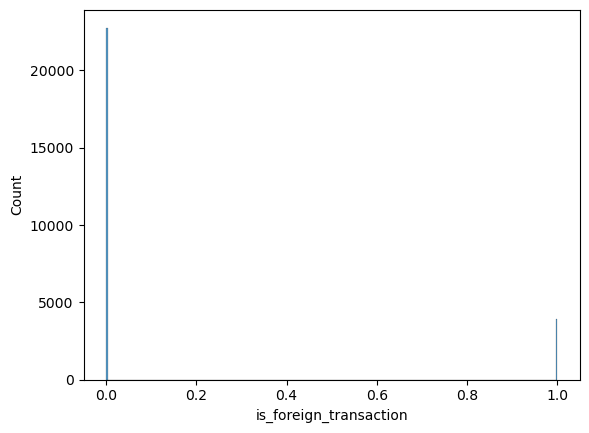

In [21]:
sns.histplot(df["is_foreign_transaction"])

<Axes: xlabel='transaction_amount', ylabel='Density'>

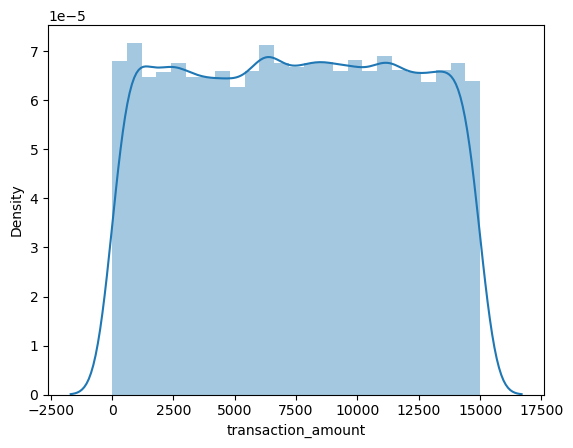

In [22]:
sns.distplot(df["transaction_amount"], bins = 25)

<Axes: xlabel='prev_fraud_flag', ylabel='account_balance'>

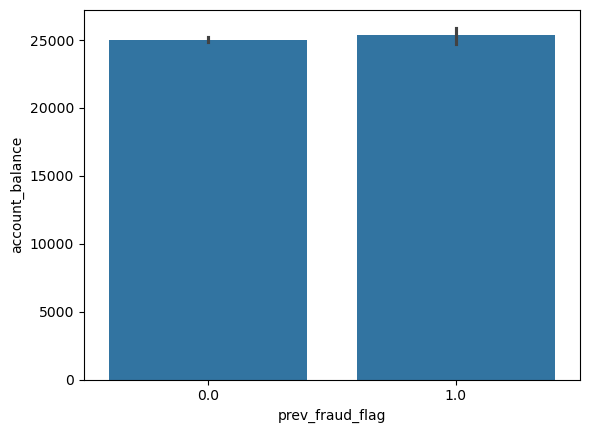

In [23]:
sns.barplot(x = df["prev_fraud_flag"], y = df["account_balance"])

<Axes: xlabel='prev_fraud_flag', ylabel='count'>

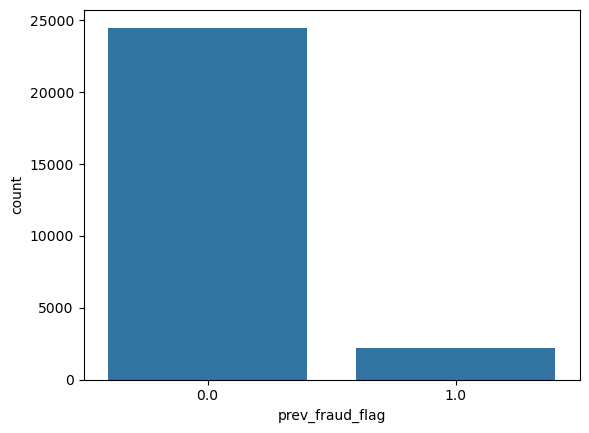

In [24]:
sns.barplot(df["prev_fraud_flag"].value_counts())

In [25]:
df.corr()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
age,1.000000,0.003766,0.010196,-0.006781,-0.008929,-0.012600,0.002245,0.004592,0.005052,-0.097345
transaction_amount,0.003766,1.000000,-0.011510,-0.002356,-0.002904,-0.000816,0.004989,0.002043,-0.000502,0.213097
account_balance,0.010196,-0.011510,1.000000,-0.009902,-0.005053,-0.001400,0.006392,0.007048,0.005309,-0.002284
num_transactions_today,-0.006781,-0.002356,-0.009902,1.000000,0.000192,-0.006465,0.003051,-0.003941,-0.002062,0.119663
is_foreign_transaction,-0.008929,-0.002904,-0.005053,0.000192,1.000000,-0.007212,-0.000746,0.003299,-0.002325,0.240862
transaction_hour,-0.012600,-0.000816,-0.001400,-0.006465,-0.007212,1.000000,-0.001327,0.001822,0.003549,0.070260
prev_fraud_flag,0.002245,0.004989,0.006392,0.003051,-0.000746,-0.001327,1.000000,0.002825,0.003628,0.262213
merchant_distance_km,0.004592,0.002043,0.007048,-0.003941,0.003299,0.001822,0.002825,1.000000,0.000405,0.260670
merchant_risk_score,0.005052,-0.000502,0.005309,-0.002062,-0.002325,0.003549,0.003628,0.000405,1.000000,0.219868
is_fraud,-0.097345,0.213097,-0.002284,0.119663,0.240862,0.070260,0.262213,0.260670,0.219868,1.000000


<Axes: >

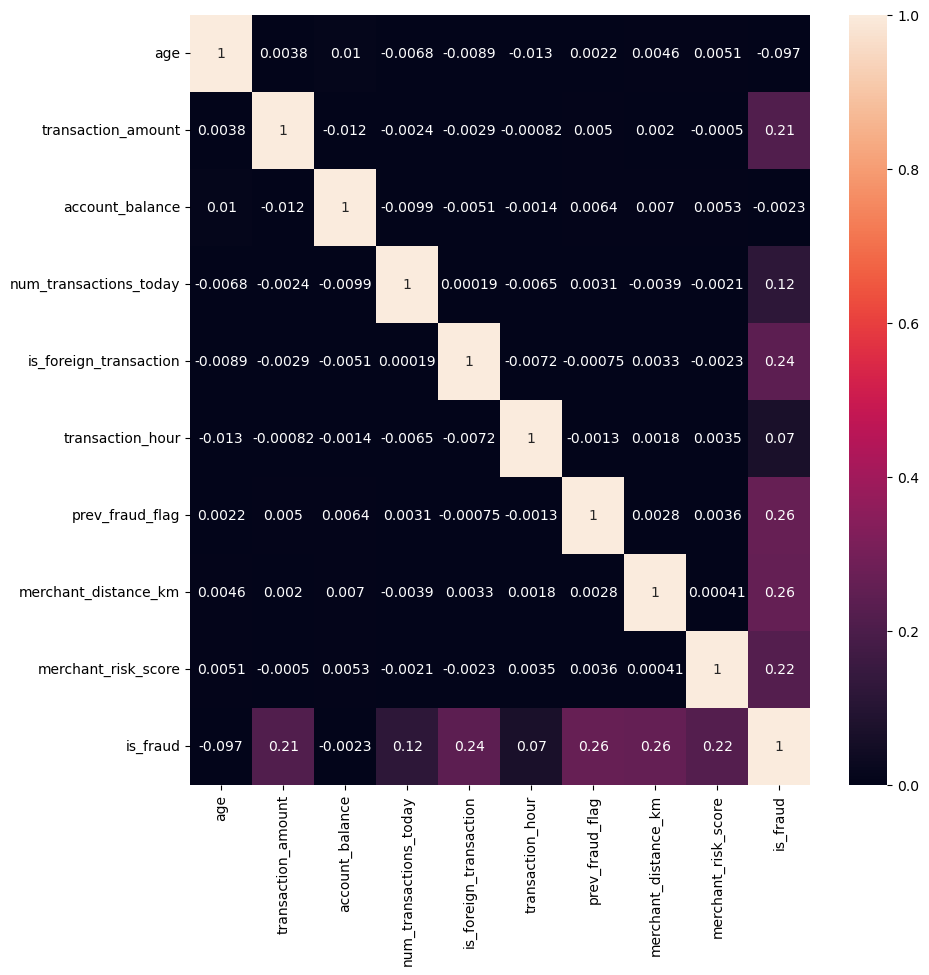

In [26]:
plt.figure(figsize = (10,10))
sns.heatmap(df.corr(), annot = True, vmin = 0, vmax = 1)

In [27]:
df.groupby("prev_fraud_flag")["merchant_distance_km"].value_counts()

prev_fraud_flag  merchant_distance_km
0.0              1441.2                  6
                 4240.4                  6
                 493.0                   5
                 550.6                   5
                 1756.7                  5
                                        ..
1.0              4986.9                  1
                 4988.7                  1
                 4990.9                  1
                 4995.7                  1
                 4998.9                  1
Name: count, Length: 21460, dtype: int64

<Axes: xlabel='count', ylabel='merchant_distance_km'>

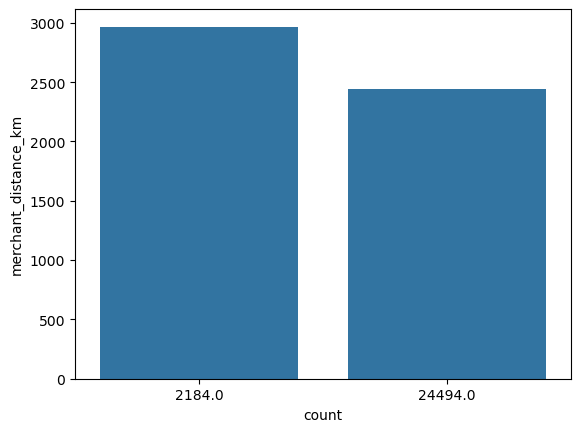

In [28]:
sns.barplot(x = df["prev_fraud_flag"].value_counts(), y = df["merchant_distance_km"])

In [29]:
df.describe()

,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
count,26678.000000,26678.000000,26678.000000,26678.000000,26678.000000,26678.000000,26678.000000,26678.000000,26678.000000
mean,7478.337323,25030.662063,25.020316,0.146488,11.445123,0.081865,2498.909289,5.507707,0.482008
std,4325.431959,14434.979879,14.144827,0.353601,6.916840,0.274164,1444.213151,2.595140,0.499686
min,2.730000,-99999.000000,1.000000,0.000000,0.000000,0.000000,0.100000,1.000000,0.000000
25%,3723.035000,12463.555000,13.000000,0.000000,5.000000,0.000000,1252.325000,3.300000,0.000000
50%,7502.515000,25061.850000,25.000000,0.000000,11.000000,0.000000,2499.900000,5.500000,0.000000
75%,11206.707500,37535.377500,37.000000,0.000000,17.000000,0.000000,3737.500000,7.800000,1.000000
max,14999.710000,49998.900000,49.000000,1.000000,28.000000,1.000000,4999.800000,10.000000,1.000000


<Axes: xlabel='prev_fraud_flag', ylabel='count'>

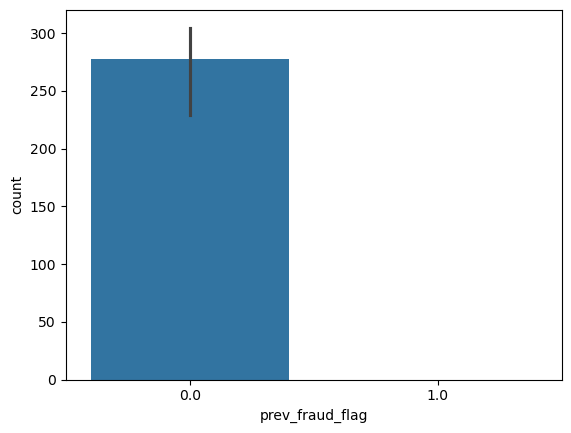

In [30]:
sns.barplot(x = df["prev_fraud_flag"], y = df["merchant_risk_score"].value_counts())

Before SMOTE:
is_fraud
0    11055
1    10287
Name: count, dtype: int64
After SMOTE:
is_fraud
1    11055
0    11055
Name: count, dtype: int64
Fitting 3 folds for each of 144 candidates, totalling 432 fits
Best Parameters:
{'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.9}

Accuracy Score:
0.7445652173913043

Confusion Matrix:
[[2102  662]
 [ 701 1871]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.76      0.76      2764
           1       0.74      0.73      0.73      2572

    accuracy                           0.74      5336
   macro avg       0.74      0.74      0.74      5336
weighted avg       0.74      0.74      0.74      5336



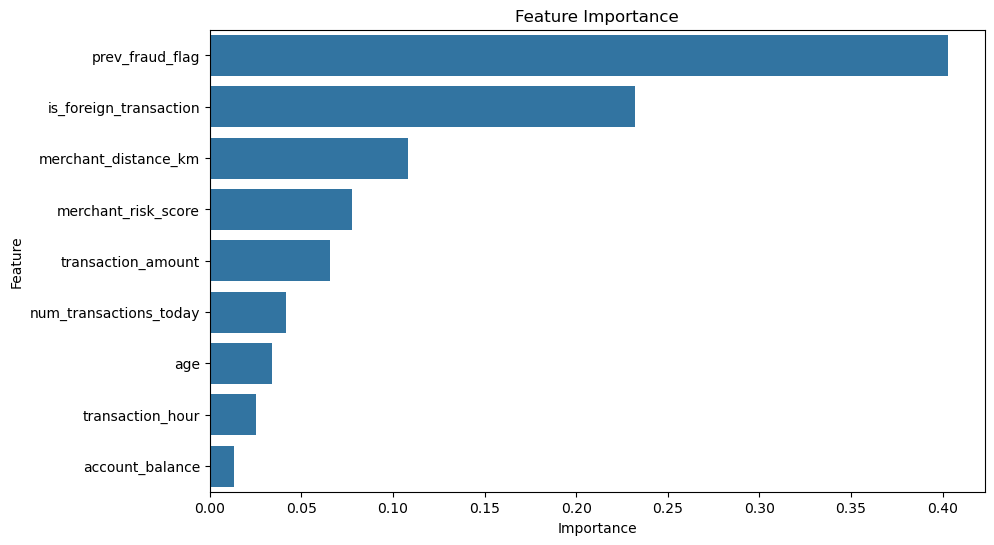

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import pickle

X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

# -----------------------------------
# 4. Train Test Split
# -----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# -----------------------------------
# 5. Balance Dataset (Important)
# -----------------------------------
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# -----------------------------------
# 6. Scale Data
# -----------------------------------
scaler = StandardScaler()

X_train_smote = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# -----------------------------------
# 7. Hyperparameter Tuning
# -----------------------------------
params = {
    'n_estimators': [200, 300, 500, 1000],
    'max_depth': [5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0]
}

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_smote, y_train_smote)

print("Best Parameters:")
print(grid.best_params_)

# -----------------------------------
# 8. Best Model
# -----------------------------------
best_model = grid.best_estimator_

# -----------------------------------
# 9. Prediction
# -----------------------------------
pred = best_model.predict(X_test_scaled)

# -----------------------------------
# 10. Results
# -----------------------------------
print("\nAccuracy Score:")
print(accuracy_score(y_test, pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))

print("\nClassification Report:")
print(classification_report(y_test, pred))

# -----------------------------------
# 11. Feature Importance
# -----------------------------------
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()

In [35]:
# Instead of pickle.dump, use the built-in XGBoost saver
best_model.save_model("my_model.json")